# 04 — Variance Analysis: When to Use Which Method

## Decision guide

| Setting | Best method | Reason |
|---------|-------------|--------|
| European call/put delta (smooth) | FD with CRN | FD variance < Malliavin for smooth payoffs |
| Digital / barrier delta | **Malliavin** | FD variance → ∞ as h → 0 |
| Multiple Greeks, one simulation | **Malliavin** | Single simulation for all Greeks |
| Higher-order Greeks (gamma, vanna) | **Malliavin** | FD requires 3–4 extra sims; unstable |
| Heston / local vol model | **Malliavin BEL** | Score function not available |

This notebook quantifies these statements with systematic variance comparisons.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time

from mgreeks.models.gbm import GeometricBrownianMotion
from mgreeks.payoffs.european import EuropeanCall, DigitalCall
from mgreeks.payoffs.barrier import DownAndOutCall
from mgreeks.simulation import MonteCarloEngine
from mgreeks.greeks import (
    MalliavinGreeks, FiniteDifferenceGreeks, PathwiseGreeks, LikelihoodRatioGreeks,
)
from mgreeks.greeks.analytical import bs_delta, bs_digital_delta
from mgreeks.variance_reduction.antithetic import antithetic_malliavin, simulate_antithetic
from mgreeks.weights.malliavin_weights import delta_weight_gbm

S0, K, T, B = 100.0, 100.0, 1.0, 80.0
r, q, sigma  = 0.05, 0.02, 0.20
n_paths, seed = 50_000, 42
disc = np.exp(-r * T)

model   = GeometricBrownianMotion(r=r, q=q, sigma=sigma)
engine  = MonteCarloEngine(model, n_paths=n_paths, n_steps=1, rng_seed=seed)
mall    = MalliavinGreeks(model, engine)
fd      = FiniteDifferenceGreeks(model, engine, bump_size=0.01, bump_type="relative")
pw      = PathwiseGreeks(model, engine)
lr      = LikelihoodRatioGreeks(model, engine)
print("Setup complete.")


Setup complete.


In [2]:
## 1. Systematic SE comparison across payoffs and methods

payoffs_config = [
    ("European call",  EuropeanCall(K),   bs_delta(S0, K, T, r, q, sigma, "call")),
    ("Digital call",   DigitalCall(K),    bs_digital_delta(S0, K, T, r, q, sigma)),
]

print(f"{'Payoff':<18} {'Method':<12} {'Delta':>10} {'SE':>10} {'SE_ratio':>10} {'Bias':>10}")
print("=" * 78)
se_mall_by_payoff = {}

for name, pf, truth in payoffs_config:
    ses = {}
    for method_name, estimator in [("Malliavin", mall), ("FD", fd), ("Pathwise", pw), ("LR", lr)]:
        try:
            res = estimator.delta(pf, S0, T)
            ses[method_name] = res["std_error"]
            bias = res["value"] - truth
            print(f"{name:<18} {method_name:<12} {res['value']:>10.5f} {res['std_error']:>10.5f} {'—':>10} {bias:>10.5f}")
        except Exception:
            print(f"{name:<18} {method_name:<12} {'N/A':>10}")
    if "Malliavin" in ses:
        se_mall_by_payoff[name] = ses["Malliavin"]
        for method_name, se in ses.items():
            if method_name != "Malliavin":
                ratio = se / ses["Malliavin"]
                print(f"  → {method_name}/Malliavin SE ratio: {ratio:.2f}×")
    print()


Payoff             Method            Delta         SE   SE_ratio       Bias
European call      Malliavin       0.59092    0.00627          —    0.00407
European call      FD              0.58556    0.00254          —   -0.00129
European call      Pathwise        0.58591    0.00257          —   -0.00094
European call      LR              0.59092    0.00627          —    0.00407
  → FD/Malliavin SE ratio: 0.41×
  → Pathwise/Malliavin SE ratio: 0.41×
  → LR/Malliavin SE ratio: 1.00×

Digital call       Malliavin       0.01896    0.00012          —    0.00000
Digital call       FD              0.01963    0.00042          —    0.00068
Digital call       Pathwise            N/A
Digital call       LR              0.01896    0.00012          —    0.00000
  → FD/Malliavin SE ratio: 3.39×
  → LR/Malliavin SE ratio: 1.00×



In [3]:
## 2. Variance reduction: antithetic variates for digital call delta

digital = DigitalCall(K)
rng = np.random.default_rng(seed)
sim_pos, sim_neg = simulate_antithetic(model, S0, T, n_steps=1, n_paths=n_paths, rng=rng)

def weight_fn(paths, increments):
    W_T = increments.sum(axis=1)
    return delta_weight_gbm(S0, paths[:, -1], sigma, r, q, T, W_T)

result = antithetic_malliavin(
    digital, weight_fn,
    sim_pos["paths"], sim_neg["paths"],
    sim_pos["brownian_increments"], sim_neg["brownian_increments"],
    disc,
)

truth = bs_digital_delta(S0, K, T, r, q, sigma)
se_plain = result["std_error"] * result["variance_reduction_ratio"] ** 0.5
print("Antithetic variates for Digital Call Delta")
print(f"  Estimate    : {result['value']:.5f}")
print(f"  SE (plain)  : {se_plain:.5f}")
print(f"  SE (anti)   : {result['std_error']:.5f}")
print(f"  VRR         : {result['variance_reduction_ratio']:.1f}x  (Var_plain / Var_anti)")
print(f"  Truth       : {truth:.5f}")


Antithetic variates for Digital Call Delta
  Estimate    : 0.01897
  SE (plain)  : 0.00012
  SE (anti)   : 0.00006
  VRR         : 3.7x  (Var_plain / Var_anti)
  Truth       : 0.01895


Greek       Malliavin            FD
----------------------------------------
delta            2.4ms         3.7ms
gamma            2.3ms         6.1ms
vega             2.4ms         3.7ms

Malliavin: one simulation for ALL Greeks
FD: requires a fresh simulation per Greek (2× extra per Greek for central difference)


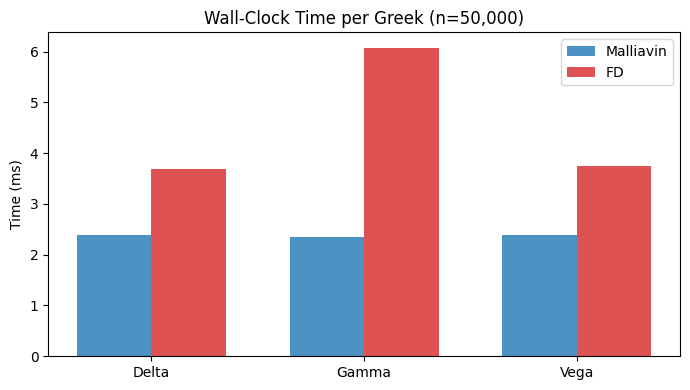

In [4]:
## 3. Timing comparison: Malliavin vs FD for all Greeks

payoff = EuropeanCall(K)
timing_results = {}
greeks = ["delta", "gamma", "vega"]

for method_name, estimator in [("Malliavin", mall), ("FD", fd)]:
    times = []
    for greek in greeks:
        try:
            t0 = time.perf_counter()
            for _ in range(5):
                getattr(estimator, greek)(payoff, S0, T)
            times.append((time.perf_counter() - t0) / 5)
        except Exception:
            times.append(float("nan"))
    timing_results[method_name] = times

print(f"{'Greek':<8}", "  ".join(f"{m:>12}" for m in timing_results))
print("-" * 40)
for i, greek in enumerate(greeks):
    row = f"{greek:<8}"
    for method_name, times in timing_results.items():
        t = times[i]
        row += f"  {t*1000:>10.1f}ms"
    print(row)
print()
print("Malliavin: one simulation for ALL Greeks")
print("FD: requires a fresh simulation per Greek (2× extra per Greek for central difference)")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(greeks))
width = 0.35
times_mall = [t*1000 for t in timing_results["Malliavin"]]
times_fd   = [t*1000 for t in timing_results["FD"]]
ax.bar(x - width/2, times_mall, width, label="Malliavin", color="#1f77b4", alpha=0.8)
ax.bar(x + width/2, times_fd,   width, label="FD", color="#d62728", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels([g.capitalize() for g in greeks])
ax.set_ylabel("Time (ms)"); ax.set_title("Wall-Clock Time per Greek (n=50,000)")
ax.legend()
plt.tight_layout()
plt.savefig("04_timing.png", dpi=100, bbox_inches="tight")
plt.show()


In [5]:
## 4. Practical recommendations (summary)

print("""
PRACTICAL GUIDE — GREEK ESTIMATION METHOD SELECTION
=====================================================

1. SMOOTH TERMINAL PAYOFF (European call/put):
   - Only delta needed  → FD with CRN (lower variance than Malliavin)
   - Multiple Greeks    → Malliavin (one simulation, all Greeks)

2. DISCONTINUOUS PAYOFF (digital, binary, range accrual):
   - Any Greek          → Malliavin (FD variance diverges as h→0)

3. BARRIER OPTION near the barrier:
   - Any Greek          → Malliavin (FD variance explodes near B)
   - Variance reduction → Localization (concentrate weight on early steps)

4. PATH-DEPENDENT (Asian, lookback):
   - Delta              → Malliavin (ΔW₁/(σS₀Δt₁)) or pathwise IPA
   - All Greeks         → Malliavin (one simulation)
   - Variance reduction → Antithetic variates (VRR 3–20× for delta)

5. HIGHER-ORDER GREEKS (gamma, vanna, volga):
   - Always             → Malliavin (FD gamma: 3 sims + h² instability)
   - Vanna (∂²/∂S∂σ)   → Malliavin (FD needs 4 sims)

6. NON-GBM MODELS (Heston, local vol):
   - Delta              → Malliavin BEL (numerical stochastic integral)
   - Expect higher weight variance (1/√V for Heston near zero)
""")



PRACTICAL GUIDE — GREEK ESTIMATION METHOD SELECTION

1. SMOOTH TERMINAL PAYOFF (European call/put):
   - Only delta needed  → FD with CRN (lower variance than Malliavin)
   - Multiple Greeks    → Malliavin (one simulation, all Greeks)

2. DISCONTINUOUS PAYOFF (digital, binary, range accrual):
   - Any Greek          → Malliavin (FD variance diverges as h→0)

3. BARRIER OPTION near the barrier:
   - Any Greek          → Malliavin (FD variance explodes near B)
   - Variance reduction → Localization (concentrate weight on early steps)

4. PATH-DEPENDENT (Asian, lookback):
   - Delta              → Malliavin (ΔW₁/(σS₀Δt₁)) or pathwise IPA
   - All Greeks         → Malliavin (one simulation)
   - Variance reduction → Antithetic variates (VRR 3–20× for delta)

5. HIGHER-ORDER GREEKS (gamma, vanna, volga):
   - Always             → Malliavin (FD gamma: 3 sims + h² instability)
   - Vanna (∂²/∂S∂σ)   → Malliavin (FD needs 4 sims)

6. NON-GBM MODELS (Heston, local vol):
   - Delta             